# FraudGuard — 08: Model Karşılaştırması

Tüm modellerin (LR, RF, XGBoost, XGBoost-optimal, Isolation Forest) final karşılaştırması.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
from pathlib import Path

np.random.seed(42)

METRICS_DIR = Path('../results/metrics')
FIGURES_DIR = Path('../results/figures')

In [2]:
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

lr_m   = load_json(METRICS_DIR / '05_baseline_metrics.json')
rf_m   = load_json(METRICS_DIR / '06_random_forest_metrics.json')
xgb_m  = load_json(METRICS_DIR / '07_xgboost_metrics.json')
th_m   = load_json(METRICS_DIR / '09_threshold_metrics.json')
if_m   = load_json(METRICS_DIR / '08_isolation_forest_metrics.json')

xgb_opt = th_m['optimal_threshold']

rows = [
    {'Model': 'Logistic Regression (0.50)',
     'Precision': lr_m['precision'],  'Recall': lr_m['recall'],
     'F1': lr_m['f1'], 'ROC-AUC': lr_m['roc_auc'], 'PR-AUC': lr_m['pr_auc'],
     'FP': lr_m['confusion_matrix']['FP'], 'FN': lr_m['confusion_matrix']['FN']},

    {'Model': 'Random Forest (0.50)',
     'Precision': rf_m['precision'],  'Recall': rf_m['recall'],
     'F1': rf_m['f1'], 'ROC-AUC': rf_m['roc_auc'], 'PR-AUC': rf_m['pr_auc'],
     'FP': rf_m['confusion_matrix']['FP'], 'FN': rf_m['confusion_matrix']['FN']},

    {'Model': 'XGBoost (0.50)',
     'Precision': xgb_m['precision'], 'Recall': xgb_m['recall'],
     'F1': xgb_m['f1'], 'ROC-AUC': xgb_m['roc_auc'], 'PR-AUC': xgb_m['pr_auc'],
     'FP': xgb_m['confusion_matrix']['FP'], 'FN': xgb_m['confusion_matrix']['FN']},

    {'Model': f'XGBoost (optimal {xgb_opt["threshold"]})',
     'Precision': xgb_opt['precision'], 'Recall': xgb_opt['recall'],
     'F1': xgb_opt['f1'], 'ROC-AUC': xgb_m['roc_auc'], 'PR-AUC': xgb_m['pr_auc'],
     'FP': xgb_opt['confusion_matrix']['FP'], 'FN': xgb_opt['confusion_matrix']['FN']},

    {'Model': 'Isolation Forest (unsupervised)',
     'Precision': if_m['precision'],  'Recall': if_m['recall'],
     'F1': if_m['f1'], 'ROC-AUC': if_m['roc_auc'], 'PR-AUC': if_m['pr_auc'],
     'FP': if_m['confusion_matrix']['FP'], 'FN': if_m['confusion_matrix']['FN']},
]

df = pd.DataFrame(rows).set_index('Model')
print('Metrik dosyaları yüklendi.')

Metrik dosyaları yüklendi.


## 1. Final Karşılaştırma Tablosu

In [3]:
metric_cols = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

print('=== Final Model Karşılaştırması ===')
print(df.to_string())
print()
print('--- En İyi Değerler ---')
for col in metric_cols:
    best_model = df[col].idxmax()
    print(f'{col:12s}: {df[col].max():.4f}  →  {best_model}')

=== Final Model Karşılaştırması ===
                                 Precision  Recall      F1  ROC-AUC  PR-AUC  FP  FN
Model                                                                              
Logistic Regression (0.50)          0.8267  0.6327  0.7168   0.9605  0.7414  13  36
Random Forest (0.50)                0.9605  0.7449  0.8391   0.9529  0.8539   3  25
XGBoost (0.50)                      0.7757  0.8469  0.8098   0.9815  0.8597  24  15
XGBoost (optimal 0.9457)            0.9195  0.8163  0.8649   0.9815  0.8597   7  18
Isolation Forest (unsupervised)     0.3084  0.3367  0.3220   0.9543  0.2180  74  65

--- En İyi Değerler ---
Precision   : 0.9605  →  Random Forest (0.50)
Recall      : 0.8469  →  XGBoost (0.50)
F1          : 0.8649  →  XGBoost (optimal 0.9457)
ROC-AUC     : 0.9815  →  XGBoost (0.50)
PR-AUC      : 0.8597  →  XGBoost (0.50)


## 2. Bar Chart Karşılaştırması

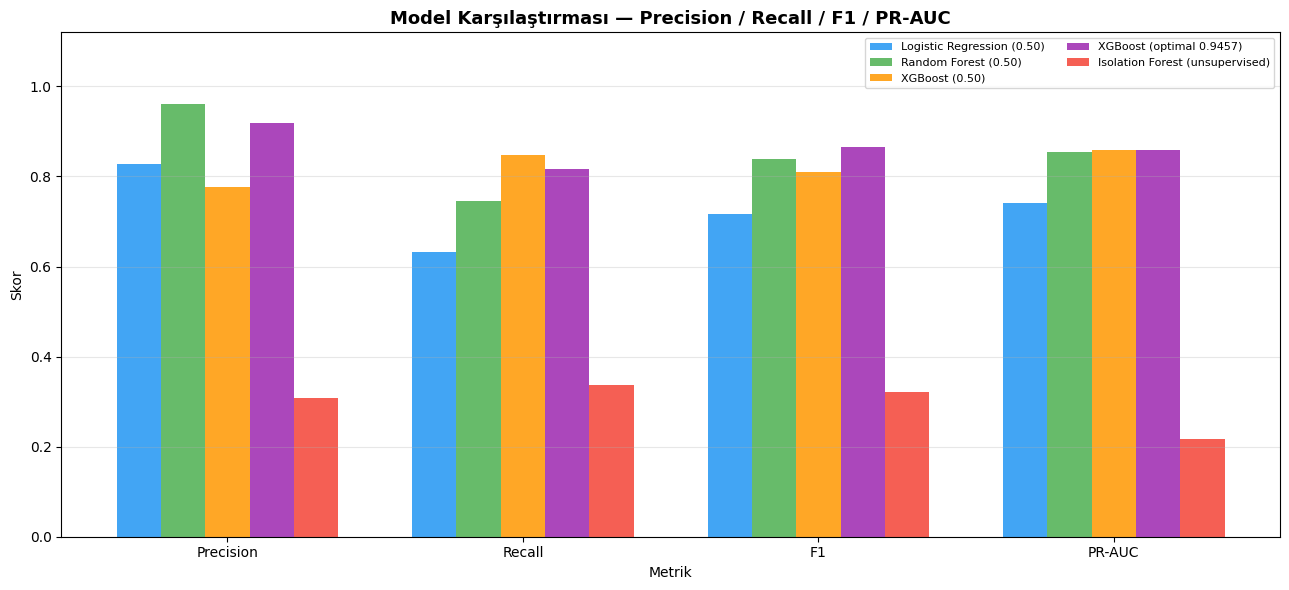

Saved: 19_model_comparison_bar.png


In [4]:
plot_metrics = ['Precision', 'Recall', 'F1', 'PR-AUC']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
models = df.index.tolist()
x = np.arange(len(plot_metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df.loc[model, m] for m in plot_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)

ax.set_xlabel('Metrik')
ax.set_ylabel('Skor')
ax.set_title('Model Karşılaştırması — Precision / Recall / F1 / PR-AUC', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '19_model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 19_model_comparison_bar.png')

## 3. Isı Haritası

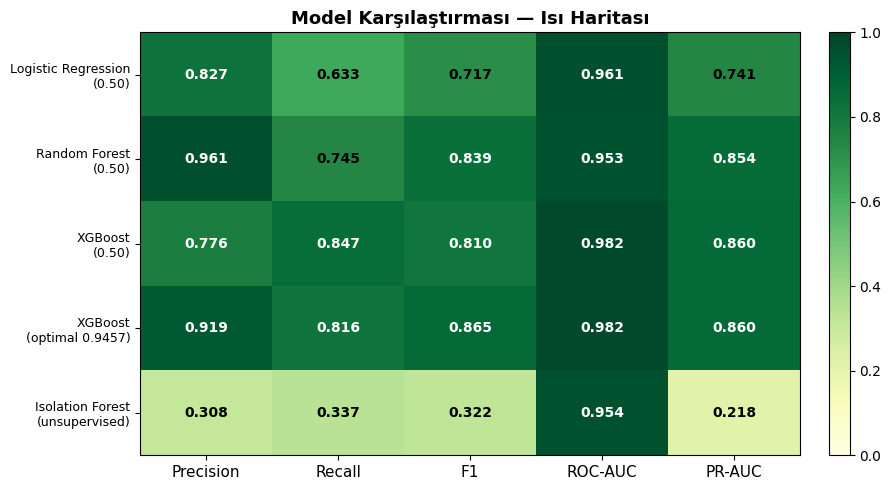

Saved: 20_model_comparison_heatmap.png


In [5]:
heat_data = df[metric_cols].astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heat_data.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels([m.replace(' (', '\n(') for m in heat_data.index], fontsize=9)

for i in range(len(heat_data)):
    for j in range(len(metric_cols)):
        val = heat_data.values[i, j]
        text_color = 'black' if val < 0.75 else 'white'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

ax.set_title('Model Karşılaştırması — Isı Haritası', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '20_model_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 20_model_comparison_heatmap.png')

## 4. Özet ve Öneri

| Senaryo | Önerilen Model | Gerekçe |
|---------|---------------|----------|
| **Fraud tespitini maksimize et** | XGBoost (eşik=0.50) | En yüksek Recall (0.847) |
| **Yanlış alarm minimumu** | XGBoost (eşik=0.9457) | FP=7, Precision=0.920 |
| **Dengeli F1** | XGBoost (eşik=0.9457) | En yüksek F1 (0.865) |
| **Etiket olmadan anomali tespiti** | Isolation Forest | Unsupervised, ROC-AUC=0.954 |

In [6]:
final = {
    'step': '10_model_comparison',
    'models': df.reset_index().rename(columns={'Model': 'model'}).to_dict(orient='records'),
    'best_per_metric': {
        col: {'model': df[col].idxmax(), 'value': round(float(df[col].max()), 4)}
        for col in metric_cols
    },
    'recommended': 'XGBoost (optimal 0.9457) — highest F1 (0.8649) with lowest FP (7)'
}

with open(METRICS_DIR / '10_final_comparison.json', 'w') as f:
    json.dump(final, f, indent=2)

print('Saved: 10_final_comparison.json')
print()
print('En iyi değerler:')
for col, info in final['best_per_metric'].items():
    print(f'  {col:10s}: {info["value"]:.4f}  →  {info["model"]}')

Saved: 10_final_comparison.json

En iyi değerler:
  Precision : 0.9605  →  Random Forest (0.50)
  Recall    : 0.8469  →  XGBoost (0.50)
  F1        : 0.8649  →  XGBoost (optimal 0.9457)
  ROC-AUC   : 0.9815  →  XGBoost (0.50)
  PR-AUC    : 0.8597  →  XGBoost (0.50)
